In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
from numba import cuda

from helpers.density_estimator import DensityEstimator
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d
from helpers.ANODE_training_utils import train_ANODE, plot_ANODE_losses
from helpers.data_transforms import preprocess_data, inverse_preprocess_data
from sklearn.preprocessing import StandardScaler, MinMaxScaler


from helpers.sampling import get_flow_samples
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples


In [4]:
SEED = 8
NUM_FEATURES = 5
NUM_COND_INPUTS = 0
CONFIG = "CATHODE_5"
TRAIN_FLOW = True
TRAIN_DIFFUSION_MODEL = False
id = "all"

In [5]:

# computing
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [6]:



path_to_config_file = f"configs/{CONFIG}.yml"
flow_training_dir = f"/pscratch/sd/r/rmastand/muon/models/{CONFIG}/{id}"
os.makedirs(flow_training_dir, exist_ok=True)



In [7]:
collections_TrackerHitPlane = [
    "IBTrackerHits",
    "IBTrackerHitsConed",
    "IETrackerHits", 
    "IETrackerHitsConed",
    "OBTrackerHits",
    "OBTrackerHitsConed", 
    "OETrackerHits",        
    "OETrackerHitsConed",          
    "VBTrackerHits",               
    "VBTrackerHitsConed",   
    "VETrackerHits",  
    "VETrackerHitsConed",        
]

collections_SimTrackerHit = [
    "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
    "InnerTrackerEndcapCollection",
    #"InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
   # "OuterTrackerBarrelCollectionConed",
    "OuterTrackerEndcapCollection",  
   # "OuterTrackerEndcapCollectionConed",
    "VertexBarrelCollection",   
   # "VertexBarrelCollectionConed",   
    "VertexEndcapCollection",
   # "VertexEndcapCollectionConed",
]



feature_labels = ["$E$", "$x$", "$y$", "$z$", "$t$", "context"]
log_vars = [0]

In [8]:

data = []
context = []

for i, collection in enumerate(collections_SimTrackerHit): # TODO coned too?

    tmp_data = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    tmp_context = int(i)*np.ones((tmp_data.shape[0],1))
    context.append(tmp_context)
    data.append(tmp_data[:int(len(tmp_data)*.1)])


data = np.vstack(data)[:,[0,2,3,4,5]]
context = np.vstack(context)

data = data[data[:,0] > 2e-6]

bins_dict = {}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), 100) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 10), np.max(data[:,i] + 10), 100) 


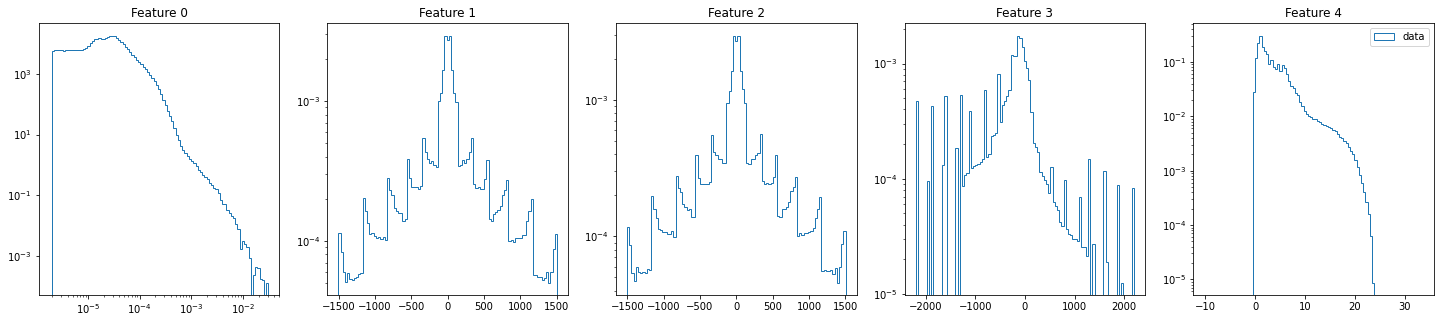

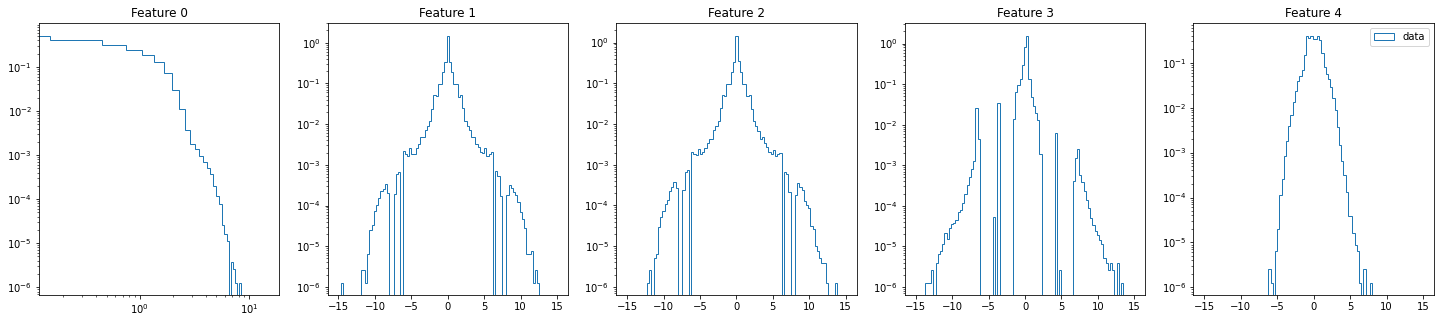

In [11]:
X_preproc = preprocess_data(data, ".")
if NUM_COND_INPUTS == 1:
    X_preproc = np.hstack([X_preproc,  context])
elif NUM_COND_INPUTS == 0:
    pass
else:
    print("ERROR")
    exit()


plot_hists_1d({"data":data}, bins_dict, log_dims=log_vars)
plt.show()

plot_hists_1d({"data":X_preproc}, {i:np.linspace(-15, 15, 100) for i in range(data.shape[1])}, log_dims=log_vars)
plt.show()


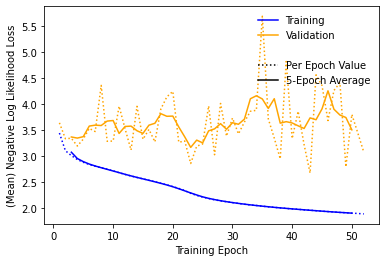

In [8]:


# plot losses
train_losses = np.load(os.path.join(flow_training_dir, f"flow_train_losses.npy"))
val_losses = np.load(os.path.join(flow_training_dir, f"flow_val_losses.npy"))
val_losses = val_losses[train_losses < 1e20]
train_losses = train_losses[train_losses < 1e20]
plot_ANODE_losses(train_losses, val_losses, yrange=None,
savefig=os.path.join(flow_training_dir, f"loss_plot"),suppress_show=False)



In [9]:
if TRAIN_FLOW:
    print("Making flow samples...")
    
    # get epoch of best val loss
    best_epoch = np.nanargmin(val_losses) - 1
    model_path = f"{flow_training_dir}/flow_epoch_{best_epoch}.par"
    
    eval_model = DensityEstimator(path_to_config_file, NUM_FEATURES,
                             eval_mode=True,
                             load_path=model_path,
                             device=device, verbose=False,
                             bound=False)


    num_samples_total = data.shape[0] 
    sample_batch_size = 8192

    samples_flow = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = get_flow_samples(eval_model, masses=None, num_samples = nn)
        samples_flow.append(loc_samples)
    samples_flow = np.concatenate(samples_flow)
    print(samples_flow.shape)

    

    X_samples = {
        "flow_samples":samples_flow
    }


    
elif TRAIN_DIFFUSION_MODEL:

    with open(path_to_config_file, "r") as ifile:
        configs_dict = yaml.safe_load(ifile)

    from tqdm import tqdm
    import functools
    from helpers.models.diffusion.diffusion_model import ScoreNet1D, marginal_prob_std, diffusion_coeff
    from helpers.models.diffusion.samplers import Euler_Maruyama_sampler, pc_sampler, ode_sampler
    
    marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=configs_dict["sigma"], device=device)
    diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=configs_dict["sigma"], device=device)

    num_steps =  1000
    signal_to_noise_ratio = 0.16
    error_tolerance = 1e-6
    
    ## Load the pre-trained checkpoint from disk.
    device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
    score_model = torch.nn.DataParallel(ScoreNet1D(marginal_prob_std=marginal_prob_std_fn, channels=configs_dict["channels"], embed_dim=configs_dict["embed_dim"]))
    score_model = score_model.to(device)
    ckpt = torch.load(f"{flow_training_dir}/ckpt.pth", map_location=device)
    score_model.load_state_dict(ckpt)

    num_samples_total = data.shape[0] // 10
    sample_batch_size = 4096

    print("Running Euler_Maruyama_sampler...") 
    samples_EM = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = Euler_Maruyama_sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn, NUM_FEATURES, 
                      nn, num_steps=num_steps, device=device).squeeze(1).detach().cpu().numpy()
        samples_EM.append(loc_samples)
    samples_EM = np.concatenate(samples_EM)
    print(samples_EM.shape)


    print("Running pc_sampler...") 
    samples_pc = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = pc_sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn, NUM_FEATURES,
                      nn, num_steps=num_steps, snr=signal_to_noise_ratio, device=device).squeeze(1).detach().cpu().numpy()
        samples_pc.append(loc_samples)
    samples_pc = np.concatenate(samples_pc)
    print(samples_pc.shape)

    print("ode_sampler pc_sampler...") 
    samples_ode = []
    for i in tqdm(range(0, num_samples_total, sample_batch_size)):
        if i + sample_batch_size > num_samples_total:
            nn = num_samples_total - i 
        else:
            nn = sample_batch_size
        loc_samples = ode_sampler(score_model, marginal_prob_std_fn, diffusion_coeff_fn, NUM_FEATURES,
                      nn, atol=error_tolerance, rtol=error_tolerance, device=device).squeeze(1)
        samples_ode.append(loc_samples.detach().cpu().numpy())
    samples_ode = np.concatenate(samples_ode)
    print(samples_ode.shape)

    X_samples = {
        "samples_EM":samples_EM,
        "samples_pc":samples_pc,
        "samples_ode":samples_ode,
    }
    
    
    


Making flow samples...


/global/homes/r/rmastand/.local/lib/python3.8/site-packages/torch/nn/init.py:405: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


DensityEstimator has 594560 parameters
Loading model parameters from /pscratch/sd/r/rmastand/muon/models/CATHODE_5/all/flow_epoch_42.par


100%|██████████| 325/325 [00:21<00:00, 14.95it/s]


(2658061, 5)


In [10]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , flow_training_dir)


/global/u1/r/rmastand/muon_collider/helpers/data_transforms.py:47: RuntimeWarning: overflow encountered in exp
  X = np.exp(X) / (1.0 + np.exp(X))
/global/u1/r/rmastand/muon_collider/helpers/data_transforms.py:47: RuntimeWarning: invalid value encountered in divide
  X = np.exp(X) / (1.0 + np.exp(X))


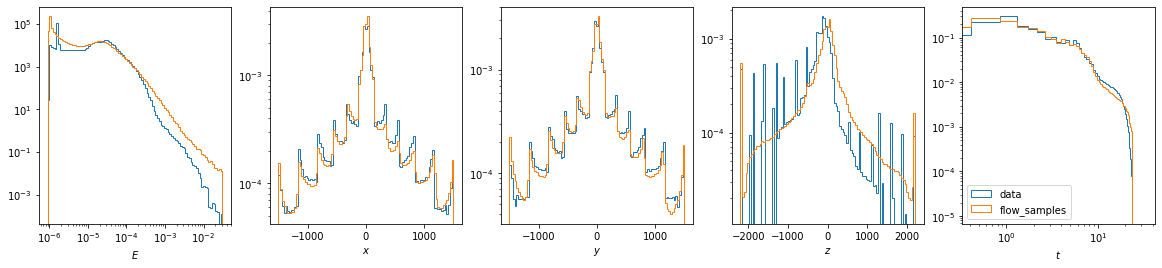

In [11]:

plot_hists_1d({"data":data, **X_samples}, bins_dict, log_dims=log_vars)
plt.show()




/tmp/ipykernel_13169/2626600876.py:93: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0, wspace=0)


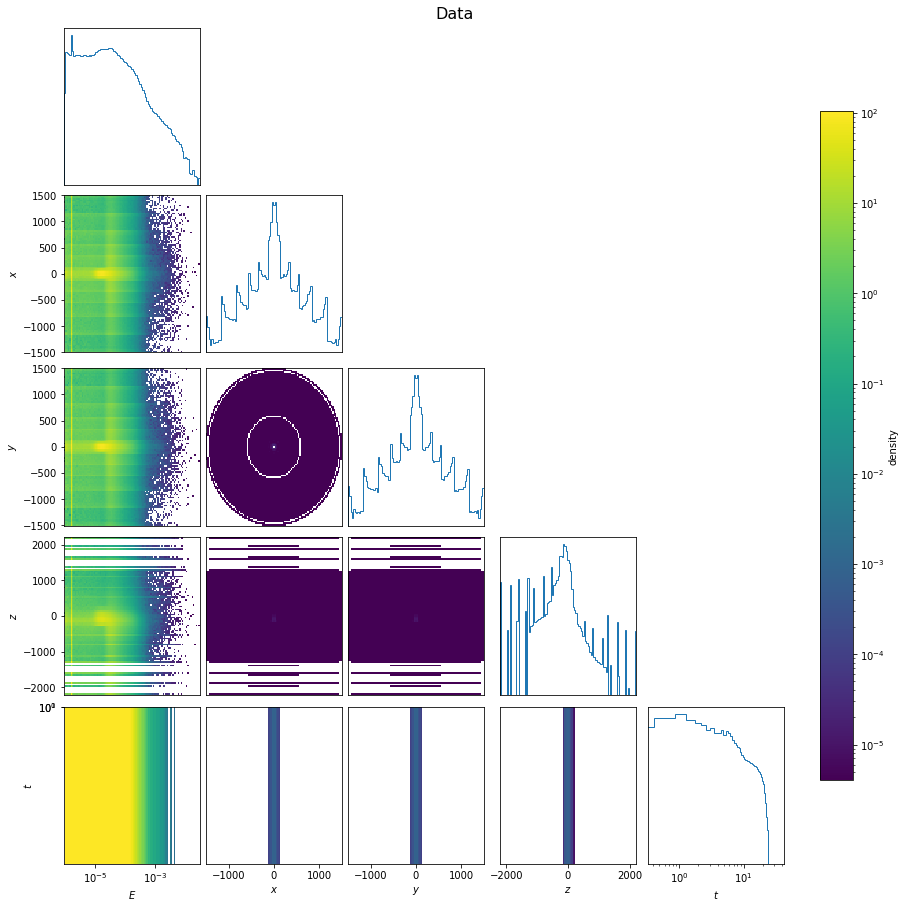

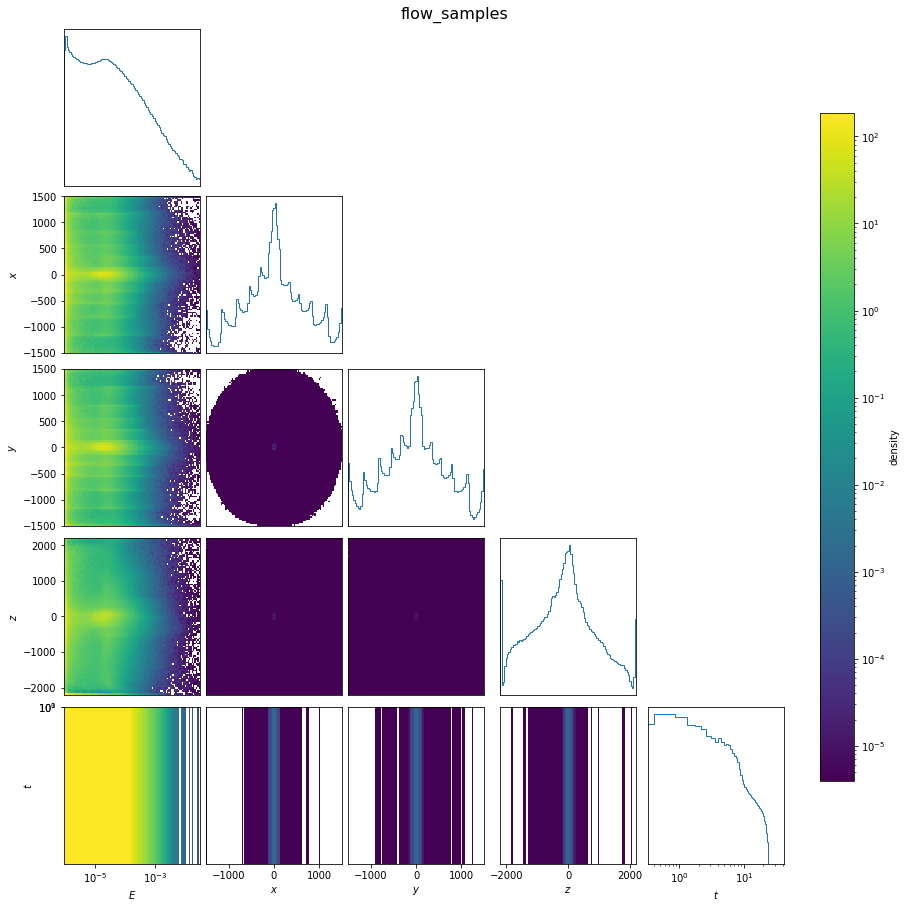

In [13]:
fig_data, axes_data = plot_corner_hist_2d(
    data,
    feature_labels=feature_labels,
    bins_dict=bins_dict,
    log_dims=(0, 4),
    title="Data",
)
plt.show()

for key in X_samples.keys():
    fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=(0, 4),
        title= key,
    )


# Train a BDT to discriminate flow from samples

In [ ]:
for key in X_samples.keys():
    
    ks_dists_samples = get_kl_dist(data, X_samples[key])
    ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples[key].shape))
    
                                            
    for i, ks_dist in enumerate(ks_dists_samples):
        print("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))
        
    
    
    auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples[key], n_runs=10, bdt_config="configs/bdt.yml")
    print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")
    


Feature 0 KL div: 0.07994060331948738 (for gaussian: 0.0008622826940389849)
Feature 1 KL div: 0.03026679974613078 (for gaussian: 0.0010676955871216087)
Feature 2 KL div: 0.03001925087497992 (for gaussian: 0.0012057661581129642)
Feature 3 KL div: 0.2322260474834852 (for gaussian: 0.0006835810013389176)
Feature 4 KL div: 0.04980698336117945 (for gaussian: 0.00041007335798537436)
On BDT 1 of 10...
